In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [3]:
df = pd.read_csv("adult.csv", header=None, names=column_names, na_values=' ?')

In [4]:
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
# Check missing values
df.isnull().sum()


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [7]:
# Drop missing values
df.dropna(inplace=True)


In [8]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
# Average age by income group
df.groupby('income')['age'].mean()


income
 <=50K    36.60806
 >50K     43.95911
Name: age, dtype: float64

In [10]:
# Average hours worked by education level
df.groupby('education')['hours-per-week'].mean().sort_values(ascending=False)


education
 Prof-school     47.963100
 Doctorate       47.832000
 Masters         44.240934
 Bachelors       42.948454
 Assoc-voc       41.954093
 Assoc-acdm      41.184524
 HS-grad         41.042073
 7th-8th         40.131059
 Some-college    39.411051
 5th-6th         38.798611
 9th             38.767033
 1st-4th         38.377483
 10th            37.464634
 Preschool       36.866667
 12th            35.697613
 11th            34.193702
Name: hours-per-week, dtype: float64

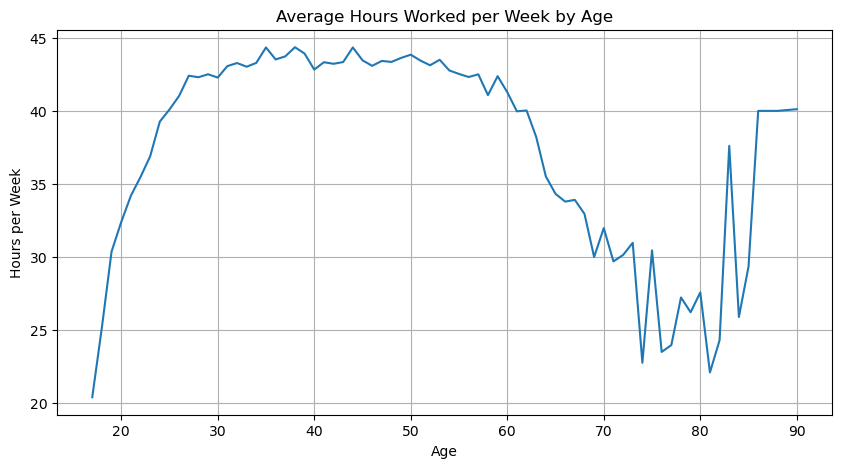

In [11]:
age_hours = df.groupby('age')['hours-per-week'].mean()

plt.figure(figsize=(10,5))
plt.plot(age_hours)
plt.title('Average Hours Worked per Week by Age')
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.grid(True)
plt.show()


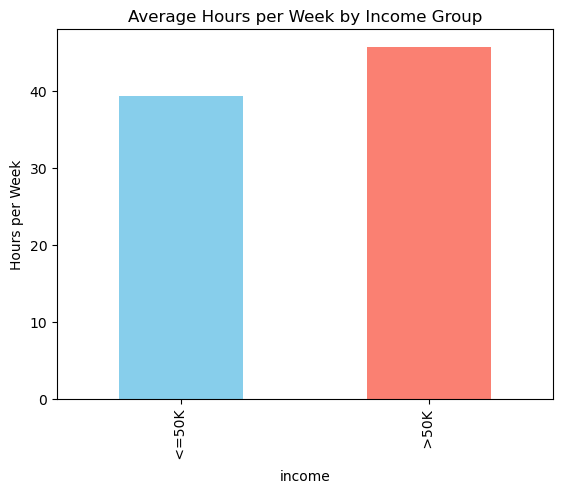

In [12]:
income_hours = df.groupby('income')['hours-per-week'].mean()

income_hours.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Hours per Week by Income Group')
plt.ylabel('Hours per Week')
plt.show()


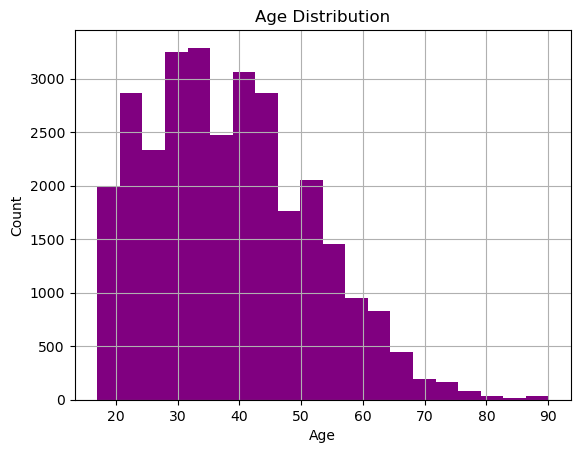

In [13]:
df['age'].hist(bins=20, color='purple')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


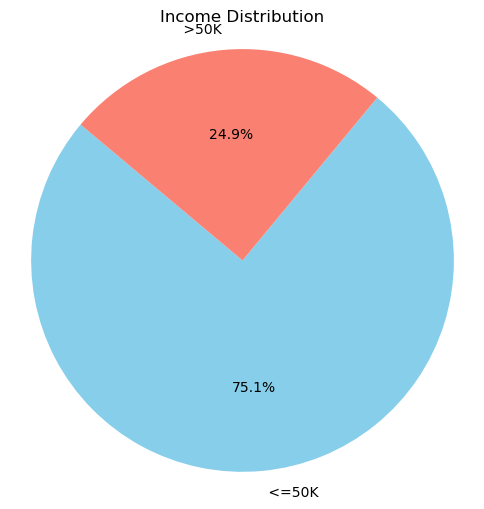

In [14]:
# Value counts of income categories
income_counts = df['income'].value_counts()

# Plot a pie chart
plt.figure(figsize=(6,6))
plt.pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'salmon'])
plt.title('Income Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
